# Spectrogram & Chromagram Feature Extraction with CNNs
This notebook outlines how a `.wav` audio file is converted into both a **mel spectrogram** and a **chromagram**, and how a chord can be predicted directly from either 2D representation using a **Convolutional Neural Network (CNN)**.

Unlike `chromagram.ipynb`, which trains XGBoost on hand-crafted summary statistics (mean/std per pitch class), this notebook feeds the *full* time-frequency representation into a CNN so the model can learn its own features. We will:
1. Extract a mel spectrogram and a chromagram for a single C major chord, for intuition.
2. Prepare a labelled dataset of spectrograms and chromagrams for every chord clip.
3. Build a CNN **from scratch**.
4. Adapt a **pretrained ResNet18** (transfer learning) for this task.
5. Train and evaluate both models on both representations (4 combinations total).
6. Compare results and discuss which approach works best, and how it could be improved further.

In [2]:
# Imports
import librosa
import pandas as pd
import numpy as np
%matplotlib inline

## Loading File and Extracting Features
The *librosa* library is used to preform low-level feature extraction such as chromagrams, Mel spectrogram, MFCC, etc.

The audio file is loaded and decoded as a *time series* `y`, represented as a one-dimensional NumPy floating point array. The variable `sr` contains the sampling rate of `y`, that is, the number of samples per second of audio.
By default, all audio is mixed to mono and resampled to 22050 Hz at load time. 

In [3]:
# Load C major chord audio file
y, sr = librosa.load('chords-test/C_acoustic_guitar_fender_fa_series_1.wav')

# Compute mel-spectrogram features
spec = librosa.feature.melspectrogram(y=y, sr=sr)

# Show first 5 time steps
# print(spec[:, :5])

# Average mel-spectrogram values across time to get a single vector per chord
spec_mean = spec.mean(axis=1)
print(f"Average mel-spectrogram vector: \n{spec_mean}")  # show average mel-spectrogram vector

Average mel-spectrogram vector: 
[1.1112891e-02 9.1268994e-02 1.1291652e-01 1.0170256e+01 1.7554979e+02
 3.2078350e+01 8.8824759e+00 5.3273869e+00 5.1422181e+00 5.5891333e+00
 1.8944261e+00 5.0958997e-01 4.4029710e-01 3.8982287e-01 1.0773328e+01
 2.6747479e+00 4.4605836e-02 9.0178114e-01 1.0629622e+01 5.3651047e+00
 1.3959908e+00 3.2416224e-01 8.7344307e-01 6.1976459e-02 3.3329439e-01
 2.5284034e-01 3.1857997e-02 3.0726941e-02 7.5718635e-03 1.0144659e+00
 8.8120848e-01 2.1111023e-01 6.5376937e-02 8.4316740e-03 1.6719643e-02
 2.3191292e-02 1.6987637e-01 1.3435755e+00 4.6004352e-01 1.6962230e-01
 2.8567794e-01 4.2774186e-02 5.5901498e-02 6.8938023e-01 2.7868521e-01
 3.5539266e-02 2.0602850e-02 1.6931494e-01 1.1438226e+00 1.2630856e-01
 4.1649997e-02 2.4188507e-02 3.2810479e-02 3.5837386e-02 9.3914561e-02
 2.5804904e-01 4.9296327e-02 2.7749052e-02 8.2996599e-03 3.7685842e-03
 5.0856653e-03 1.0408159e-02 1.1269467e-02 4.4728510e-02 3.6554441e-02
 2.4222959e-02 3.0001799e-02 1.9321404e-02 1

[Text(0.5, 1.0, 'Mel-frequency spectrogram')]

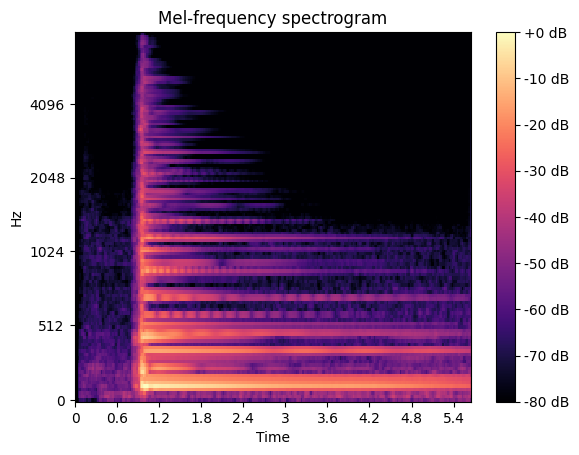

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
S_dB = librosa.power_to_db(spec, ref=np.max)
img = librosa.display.specshow(S_dB, x_axis='time',
                         y_axis='mel', sr=sr,
                         fmax=8000, ax=ax)
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set(title='Mel-frequency spectrogram')

## Chroma Features
For comparison, we also extract a **chromagram** for the same clip. Chroma features collapse all octaves of a pitch class into 12 bins (C, C#, D, ... B), capturing *which notes* are present regardless of octave — useful for chord identity. For this C major chord we expect C, E and G to stand out.

In [5]:
# Compute chroma features for the same C major chord clip
chroma = librosa.feature.chroma_cqt(y=y, sr=sr)

# Average chroma values across time to get a single vector per chord
chroma_mean = chroma.mean(axis=1)
print(f"Average chroma vector: \n{chroma_mean}")

Average chroma vector: 
[0.9801353  0.17391993 0.19715185 0.10917716 0.36052847 0.09246563
 0.0876564  0.38373512 0.13390033 0.16097637 0.15296954 0.21582028]


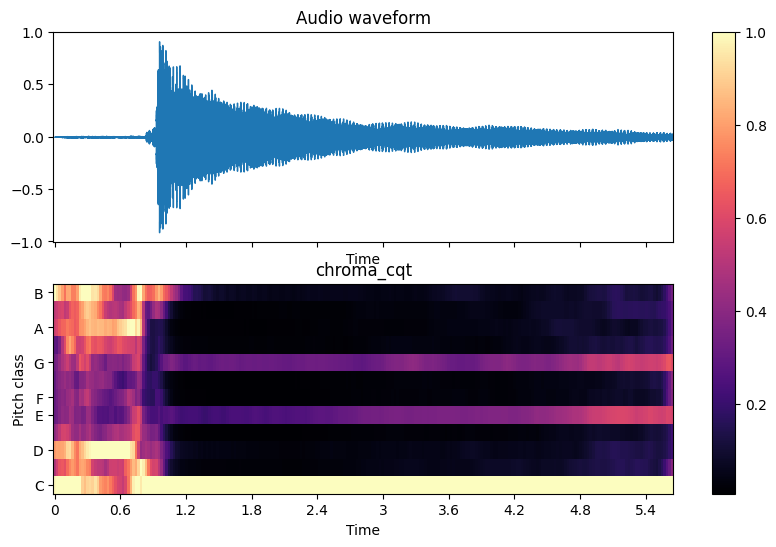

In [6]:
fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(10, 6))
librosa.display.waveshow(y, sr=sr, ax=ax[0])
ax[0].set(title='Audio waveform')
img = librosa.display.specshow(chroma, y_axis='chroma', x_axis='time', ax=ax[1])
ax[1].set(title='chroma_cqt')
fig.colorbar(img, ax=ax)

## From Hand-Crafted Statistics to CNNs
`chromagram.ipynb` reduces each clip to a 24-value vector (mean + std per pitch class) and trains XGBoost on that table — this works well, but it throws away *how the spectrum evolves over time*.

A CNN can instead consume the full 2D representation (frequency/pitch-class bins × time frames) and learn its own spatial features, the same way a CNN learns edges and textures from an image. We will build two datasets — one of mel spectrograms, one of chromagrams — and train two kinds of CNN on each:
- A small **CNN built from scratch**.
- A **pretrained ResNet18** (trained on ImageNet) adapted via transfer learning.

This gives us 4 model/representation combinations to compare.

### Preparing the data
The CSVs used by `chromagram.ipynb` (`data/processed/train.csv` / `test.csv`) only store the *aggregated* 24-feature vectors, not the full 2D arrays a CNN needs. [`src/data/prepare_cnn_data.py`](../src/data/prepare_cnn_data.py) re-processes the same source dataset (`rodriler/isolated-guitar-chords`) and, for every clip, saves a **fixed-size mel spectrogram** (128 mel bins × 128 time frames) and a **fixed-size chromagram** (12 pitch-class bins × 128 time frames) alongside its chord label — keeping the same train/test split and chord vocabulary as the existing CSVs. Variable-length clips are padded/truncated along the time axis so every sample has an identical shape, which is required to batch them for CNN training.

The script writes `data/processed/cnn/train.npz` and `data/processed/cnn/test.npz`, each containing a `spectrogram` array, a `chroma` array and a `label` array. Run it once — it downloads the dataset (cached by `huggingface_hub` afterwards) and caches its output, so re-running the notebook won't recompute it.

In [7]:
import os
import subprocess
import sys

cnn_train_path = "../Backend/data/processed/cnn/train.npz"
cnn_test_path = "../Backend/data/processed/cnn/test.npz"

if not (os.path.exists(cnn_train_path) and os.path.exists(cnn_test_path)):
    subprocess.run([sys.executable, "src/data/prepare_cnn_data.py"], cwd="../Backend", check=True)
else:
    print("CNN dataset already prepared, skipping extraction.")

CNN dataset already prepared, skipping extraction.


## Loading the CNN Dataset
We use **PyTorch** to build and train the CNNs, and **scikit-learn** to encode chord labels and report evaluation metrics, consistent with the metrics used in `chromagram.ipynb`.

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

2.11.0+cu128
12.8
True
1
Using device: cuda


In [9]:
train_npz = np.load(cnn_train_path)
test_npz = np.load(cnn_test_path)

# Fit the label encoder on the train split, reuse it for the test split
label_enc = LabelEncoder()
label_enc.fit(train_npz["label"])
num_classes = len(label_enc.classes_)

print(f"Train samples: {len(train_npz['label'])}, Test samples: {len(test_npz['label'])}")
print(f"Spectrogram shape: {train_npz['spectrogram'].shape[1:]}, Chroma shape: {train_npz['chroma'].shape[1:]}")
print(f"Chord classes ({num_classes}): {list(label_enc.classes_)}")

Train samples: 633, Test samples: 147
Spectrogram shape: (128, 128), Chroma shape: (12, 128)
Chord classes (25): [np.str_('A'), np.str_('A#'), np.str_('A#m'), np.str_('Am'), np.str_('B'), np.str_('Bm'), np.str_('C'), np.str_('C#'), np.str_('C#m'), np.str_('Cm'), np.str_('D'), np.str_('D#'), np.str_('D#m'), np.str_('Dm'), np.str_('E'), np.str_('Em'), np.str_('F'), np.str_('F#'), np.str_('F#m'), np.str_('Fm'), np.str_('G'), np.str_('G#'), np.str_('G#m'), np.str_('Gm'), np.str_('Noise')]


### A Common Dataset Class
The spectrogram (128×128) and chroma (12×128) arrays have different shapes. So the same network architectures can be reused for both, the `Dataset` below resizes every sample to a common `IMAGE_SIZE × IMAGE_SIZE` "image" via bilinear interpolation, then standardizes it to zero mean / unit variance (spectrograms and chromagrams aren't natural images, so we skip ImageNet normalization statistics and just normalize per-sample).

In [10]:
IMAGE_SIZE = 128

class ChordSpectralDataset(Dataset):
    def __init__(self, features, labels, label_encoder, image_size=IMAGE_SIZE):
        self.features = features.astype(np.float32)
        self.labels = label_encoder.transform(labels)
        self.image_size = image_size

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.features[idx]).unsqueeze(0).unsqueeze(0)  # (1, 1, H, W)
        x = F.interpolate(x, size=(self.image_size, self.image_size), mode="bilinear", align_corners=False)
        x = x.squeeze(0)  # (1, image_size, image_size)
        x = (x - x.mean()) / (x.std() + 1e-6)
        return x, self.labels[idx]

In [11]:
BATCH_SIZE = 16

def make_loaders(feature_key):
    train_ds = ChordSpectralDataset(train_npz[feature_key], train_npz["label"], label_enc)
    test_ds = ChordSpectralDataset(test_npz[feature_key], test_npz["label"], label_enc)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, test_loader

spec_train_loader, spec_test_loader = make_loaders("spectrogram")
chroma_train_loader, chroma_test_loader = make_loaders("chroma")

## Building a CNN from Scratch
A small convolutional network: four `Conv → BatchNorm → ReLU` blocks that progressively downsample the input, followed by global average pooling and a linear classifier head. `AdaptiveAvgPool2d` makes the final feature map a fixed `128`-length vector regardless of input resolution, so the same architecture works for both representations.

In [12]:
class ChordCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

## Using a Pretrained CNN (Transfer Learning with ResNet18)
Instead of learning convolutional filters from scratch, we reuse **ResNet18** pretrained on ImageNet. Its early layers already detect generic textures and edges, which can transfer to spectrogram-like images even though they aren't photographs.

To adapt it:
- ResNet18 expects **3-channel** input, so we repeat our single-channel image across the RGB channels.
- We **freeze the pretrained backbone** (its weights are not updated) and only train a new final fully-connected layer mapped to our `num_classes` chords — the standard "feature extractor" style of transfer learning, which trains fast and resists overfitting on our small dataset.

In [13]:
from torchvision.models import resnet18, ResNet18_Weights

def build_resnet(num_classes, freeze_backbone=True):
    model = resnet18(weights=ResNet18_Weights.DEFAULT)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)  # new head is always trainable
    return model

## Training and Evaluation Helpers
The two models share the same training loop. The only difference is that the ResNet expects 3 input channels, so `use_three_channels` repeats the single-channel image when needed.

In [14]:
def train_model(model, train_loader, test_loader, epochs=20, lr=1e-3, use_three_channels=False):
    model.to(device)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for x, y in train_loader:
            if use_three_channels:
                x = x.repeat(1, 3, 1, 1)
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for x, y in test_loader:
                if use_three_channels:
                    x = x.repeat(1, 3, 1, 1)
                x, y = x.to(device), y.to(device)
                logits = model(x)
                val_loss += criterion(logits, y).item() * x.size(0)
                correct += (logits.argmax(1) == y).sum().item()
        val_loss /= len(test_loader.dataset)
        val_acc = correct / len(test_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"Epoch {epoch + 1:>2}/{epochs} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

    return history


def get_predictions(model, loader, use_three_channels=False):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            if use_three_channels:
                x = x.repeat(1, 3, 1, 1)
            preds = model(x.to(device)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())
    return np.array(all_labels), np.array(all_preds)


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].plot(history["train_loss"], label="train")
    axes[0].plot(history["val_loss"], label="val")
    axes[0].set(title=f"{title} — loss", xlabel="epoch")
    axes[0].legend()
    axes[1].plot(history["val_acc"])
    axes[1].set(title=f"{title} — val accuracy", xlabel="epoch")
    fig.tight_layout()
    plt.show()


results = {}  # collects metrics for the final comparison table

def evaluate_and_record(name, model, loader, use_three_channels=False):
    y_true, y_pred = get_predictions(model, loader, use_three_channels)
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    results[name] = {"accuracy": acc, "macro_f1": macro_f1}

    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f}  |  Macro F1: {macro_f1:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=label_enc.classes_, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(9, 8))
    img = ax.imshow(cm, cmap="Blues")
    ax.set(title=f"Confusion matrix — {name}", xlabel="Predicted", ylabel="True")
    ax.set_xticks(range(num_classes))
    ax.set_yticks(range(num_classes))
    ax.set_xticklabels(label_enc.classes_, rotation=90)
    ax.set_yticklabels(label_enc.classes_)
    fig.colorbar(img, ax=ax)
    fig.tight_layout()
    plt.show()

    return y_true, y_pred

## Spectrogram — CNN From Scratch

Epoch  1/20 - train_loss: 3.0336 - val_loss: 3.1298 - val_acc: 0.0612
Epoch  2/20 - train_loss: 2.5726 - val_loss: 2.5833 - val_acc: 0.2993
Epoch  3/20 - train_loss: 2.1226 - val_loss: 2.2070 - val_acc: 0.5782
Epoch  4/20 - train_loss: 1.6888 - val_loss: 2.2103 - val_acc: 0.3878
Epoch  5/20 - train_loss: 1.2532 - val_loss: 1.8928 - val_acc: 0.5374
Epoch  6/20 - train_loss: 0.9093 - val_loss: 1.5254 - val_acc: 0.6735
Epoch  7/20 - train_loss: 0.6748 - val_loss: 1.5824 - val_acc: 0.5714
Epoch  8/20 - train_loss: 0.4975 - val_loss: 1.2819 - val_acc: 0.7143
Epoch  9/20 - train_loss: 0.3909 - val_loss: 1.1583 - val_acc: 0.7211
Epoch 10/20 - train_loss: 0.3433 - val_loss: 1.0128 - val_acc: 0.7483
Epoch 11/20 - train_loss: 0.2405 - val_loss: 1.0847 - val_acc: 0.6871
Epoch 12/20 - train_loss: 0.1972 - val_loss: 0.8405 - val_acc: 0.7687
Epoch 13/20 - train_loss: 0.1649 - val_loss: 1.2246 - val_acc: 0.6599
Epoch 14/20 - train_loss: 0.1356 - val_loss: 1.3090 - val_acc: 0.6531
Epoch 15/20 - train_

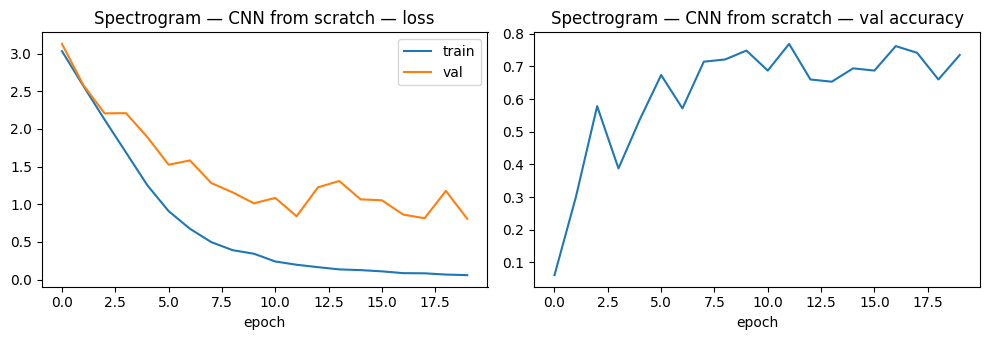

In [15]:
spec_scratch_model = ChordCNN(num_classes)
spec_scratch_history = train_model(spec_scratch_model, spec_train_loader, spec_test_loader, epochs=20)
plot_history(spec_scratch_history, "Spectrogram — CNN from scratch")


=== Spectrogram - CNN from scratch ===
Accuracy: 0.7347  |  Macro F1: 0.7020

              precision    recall  f1-score   support

           A       0.00      0.00      0.00         6
          A#       1.00      1.00      1.00         6
         A#m       1.00      1.00      1.00         6
          Am       0.24      1.00      0.39         6
           B       0.00      0.00      0.00         6
          Bm       0.50      1.00      0.67         6
           C       1.00      0.83      0.91         6
          C#       0.86      1.00      0.92         6
         C#m       1.00      0.83      0.91         6
          Cm       1.00      0.50      0.67         6
           D       0.00      0.00      0.00         6
          D#       1.00      1.00      1.00         6
         D#m       1.00      0.83      0.91         6
          Dm       1.00      0.83      0.91         6
           E       0.62      0.83      0.71         6
          Em       1.00      0.83      0.91         6
  

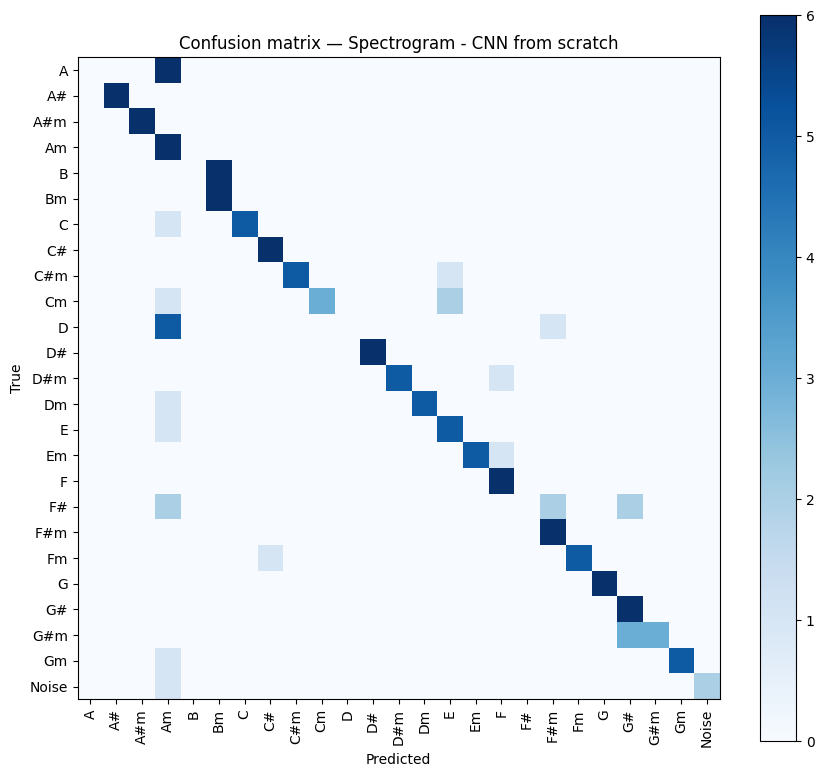

In [16]:
_ = evaluate_and_record("Spectrogram - CNN from scratch", spec_scratch_model, spec_test_loader)

## Spectrogram — Pretrained ResNet18

Epoch  1/10 - train_loss: 3.2920 - val_loss: 3.2420 - val_acc: 0.0952
Epoch  2/10 - train_loss: 2.6017 - val_loss: 3.0153 - val_acc: 0.1429
Epoch  3/10 - train_loss: 2.2774 - val_loss: 2.8356 - val_acc: 0.1633
Epoch  4/10 - train_loss: 1.9800 - val_loss: 2.8032 - val_acc: 0.1701
Epoch  5/10 - train_loss: 1.7113 - val_loss: 2.7659 - val_acc: 0.1905
Epoch  6/10 - train_loss: 1.5532 - val_loss: 2.8329 - val_acc: 0.1905
Epoch  7/10 - train_loss: 1.3855 - val_loss: 2.8159 - val_acc: 0.1905
Epoch  8/10 - train_loss: 1.2489 - val_loss: 2.8318 - val_acc: 0.1769
Epoch  9/10 - train_loss: 1.1590 - val_loss: 2.8456 - val_acc: 0.2245
Epoch 10/10 - train_loss: 1.0572 - val_loss: 2.8565 - val_acc: 0.2517


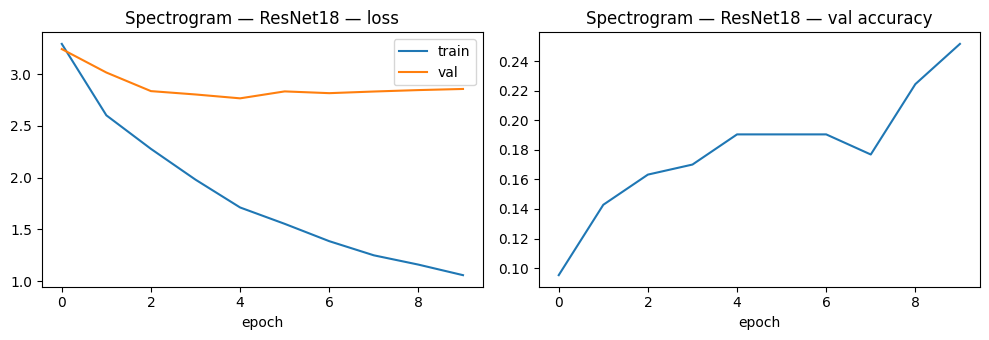

In [17]:
spec_resnet_model = build_resnet(num_classes)
spec_resnet_history = train_model(spec_resnet_model, spec_train_loader, spec_test_loader, epochs=10, use_three_channels=True)
plot_history(spec_resnet_history, "Spectrogram — ResNet18")


=== Spectrogram - ResNet18 (pretrained) ===
Accuracy: 0.2517  |  Macro F1: 0.2175

              precision    recall  f1-score   support

           A       0.25      0.17      0.20         6
          A#       0.17      0.17      0.17         6
         A#m       0.25      0.50      0.33         6
          Am       0.20      0.17      0.18         6
           B       0.00      0.00      0.00         6
          Bm       0.00      0.00      0.00         6
           C       0.50      0.17      0.25         6
          C#       0.31      0.67      0.42         6
         C#m       0.00      0.00      0.00         6
          Cm       1.00      0.17      0.29         6
           D       0.00      0.00      0.00         6
          D#       0.75      0.50      0.60         6
         D#m       0.25      0.17      0.20         6
          Dm       0.50      0.50      0.50         6
           E       0.11      0.17      0.13         6
          Em       0.40      0.67      0.50        

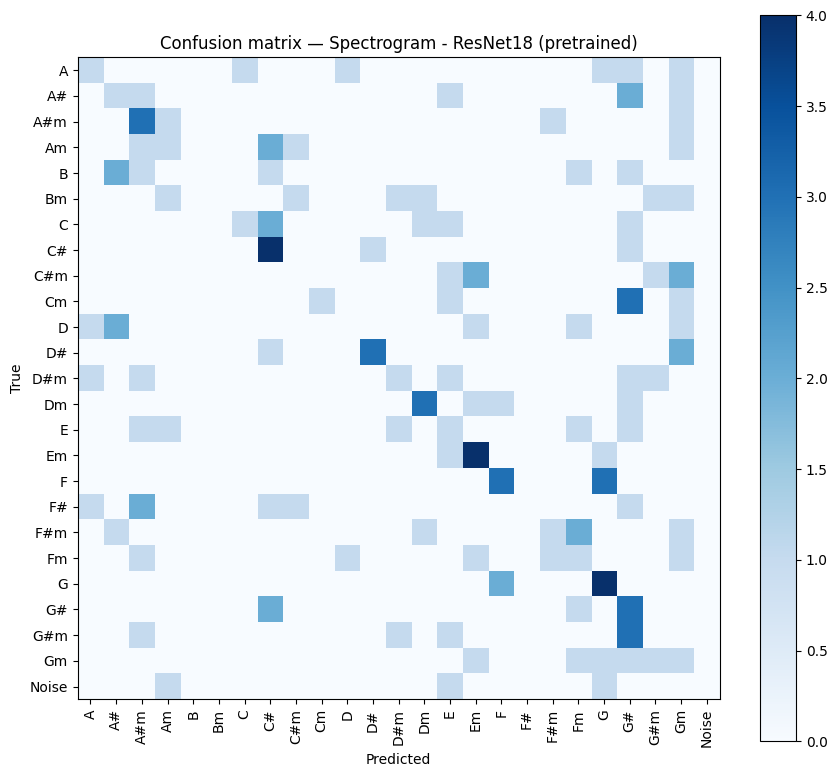

In [18]:
_ = evaluate_and_record("Spectrogram - ResNet18 (pretrained)", spec_resnet_model, spec_test_loader, use_three_channels=True)

## Chromagram — CNN From Scratch
Same architecture and training procedure, now applied to the chromagram dataset instead of the spectrogram one.

Epoch  1/20 - train_loss: 3.1214 - val_loss: 3.1529 - val_acc: 0.0680
Epoch  2/20 - train_loss: 2.8901 - val_loss: 3.0524 - val_acc: 0.0612
Epoch  3/20 - train_loss: 2.6146 - val_loss: 2.7680 - val_acc: 0.1973
Epoch  4/20 - train_loss: 2.3038 - val_loss: 2.5849 - val_acc: 0.2993
Epoch  5/20 - train_loss: 2.0277 - val_loss: 2.3102 - val_acc: 0.3810
Epoch  6/20 - train_loss: 1.7557 - val_loss: 2.1098 - val_acc: 0.4898
Epoch  7/20 - train_loss: 1.5263 - val_loss: 2.0350 - val_acc: 0.5238
Epoch  8/20 - train_loss: 1.3203 - val_loss: 1.8869 - val_acc: 0.4898
Epoch  9/20 - train_loss: 1.1394 - val_loss: 1.6304 - val_acc: 0.5442
Epoch 10/20 - train_loss: 1.0117 - val_loss: 1.7832 - val_acc: 0.5170
Epoch 11/20 - train_loss: 0.8899 - val_loss: 1.5956 - val_acc: 0.6531
Epoch 12/20 - train_loss: 0.7655 - val_loss: 1.5676 - val_acc: 0.5510
Epoch 13/20 - train_loss: 0.7059 - val_loss: 1.5377 - val_acc: 0.6395
Epoch 14/20 - train_loss: 0.6141 - val_loss: 1.4782 - val_acc: 0.6531
Epoch 15/20 - train_

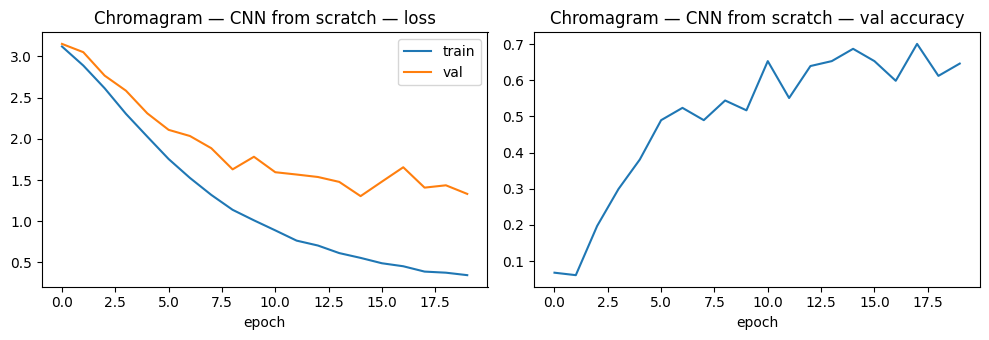

In [19]:
chroma_scratch_model = ChordCNN(num_classes)
chroma_scratch_history = train_model(chroma_scratch_model, chroma_train_loader, chroma_test_loader, epochs=20)
plot_history(chroma_scratch_history, "Chromagram — CNN from scratch")


=== Chromagram - CNN from scratch ===
Accuracy: 0.6463  |  Macro F1: 0.6116

              precision    recall  f1-score   support

           A       0.00      0.00      0.00         6
          A#       1.00      0.83      0.91         6
         A#m       0.83      0.83      0.83         6
          Am       0.50      1.00      0.67         6
           B       1.00      0.50      0.67         6
          Bm       0.71      0.83      0.77         6
           C       0.40      1.00      0.57         6
          C#       0.60      1.00      0.75         6
         C#m       0.00      0.00      0.00         6
          Cm       0.50      0.17      0.25         6
           D       0.00      0.00      0.00         6
          D#       0.83      0.83      0.83         6
         D#m       0.33      0.50      0.40         6
          Dm       1.00      0.50      0.67         6
           E       0.44      0.67      0.53         6
          Em       0.75      1.00      0.86         6
   

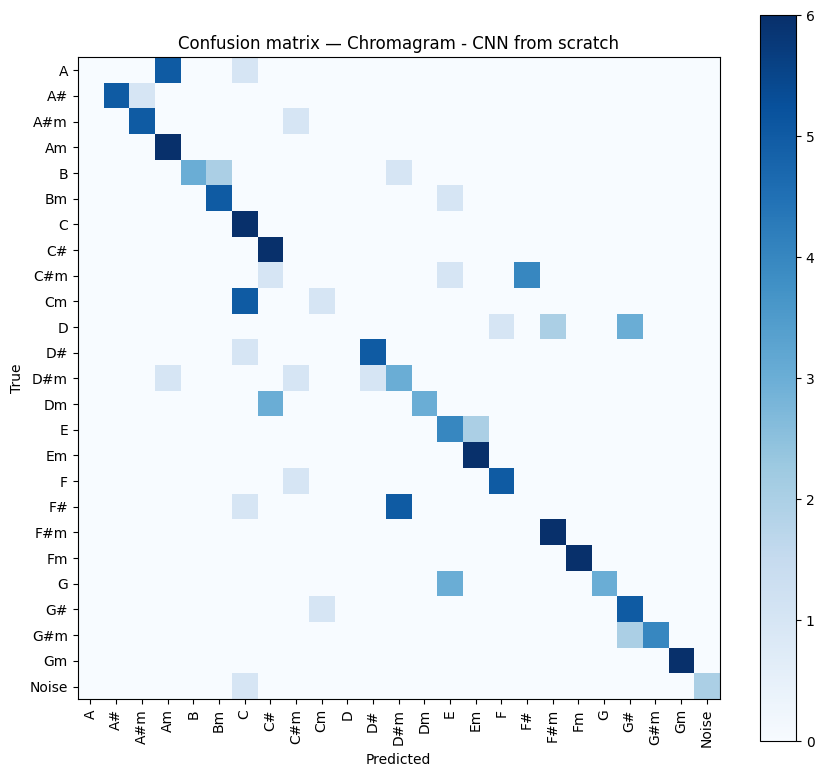

In [20]:
_ = evaluate_and_record("Chromagram - CNN from scratch", chroma_scratch_model, chroma_test_loader)

## Chromagram — Pretrained ResNet18

Epoch  1/10 - train_loss: 3.2743 - val_loss: 3.3375 - val_acc: 0.0544
Epoch  2/10 - train_loss: 2.5630 - val_loss: 3.0725 - val_acc: 0.1224
Epoch  3/10 - train_loss: 2.1055 - val_loss: 2.8300 - val_acc: 0.1905
Epoch  4/10 - train_loss: 1.6956 - val_loss: 2.7093 - val_acc: 0.2177
Epoch  5/10 - train_loss: 1.5006 - val_loss: 2.6257 - val_acc: 0.2653
Epoch  6/10 - train_loss: 1.2908 - val_loss: 2.5237 - val_acc: 0.2653
Epoch  7/10 - train_loss: 1.1044 - val_loss: 2.5429 - val_acc: 0.2653
Epoch  8/10 - train_loss: 0.9952 - val_loss: 2.5811 - val_acc: 0.2177
Epoch  9/10 - train_loss: 0.9317 - val_loss: 2.5439 - val_acc: 0.2653
Epoch 10/10 - train_loss: 0.8268 - val_loss: 2.5144 - val_acc: 0.2517


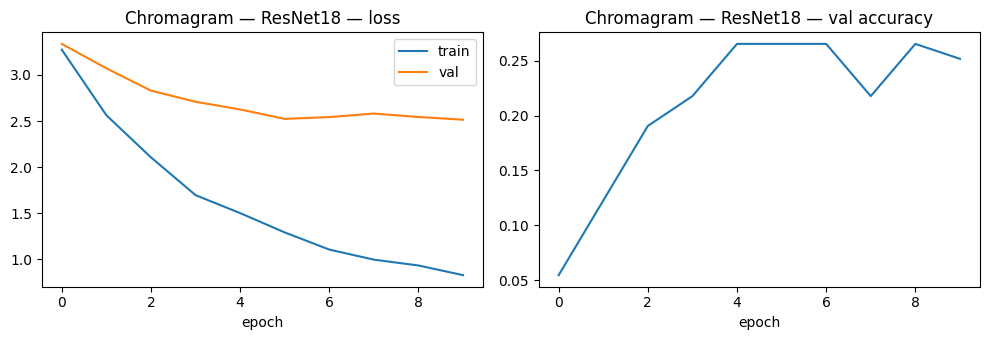

In [21]:
chroma_resnet_model = build_resnet(num_classes)
chroma_resnet_history = train_model(chroma_resnet_model, chroma_train_loader, chroma_test_loader, epochs=10, use_three_channels=True)
plot_history(chroma_resnet_history, "Chromagram — ResNet18")


=== Chromagram - ResNet18 (pretrained) ===
Accuracy: 0.2517  |  Macro F1: 0.2519

              precision    recall  f1-score   support

           A       0.33      0.17      0.22         6
          A#       0.40      0.33      0.36         6
         A#m       0.25      0.17      0.20         6
          Am       0.25      0.17      0.20         6
           B       0.00      0.00      0.00         6
          Bm       0.56      0.83      0.67         6
           C       0.57      0.67      0.62         6
          C#       0.00      0.00      0.00         6
         C#m       0.00      0.00      0.00         6
          Cm       0.40      0.33      0.36         6
           D       0.00      0.00      0.00         6
          D#       0.50      0.33      0.40         6
         D#m       0.07      0.17      0.10         6
          Dm       0.38      0.50      0.43         6
           E       0.10      0.50      0.17         6
          Em       0.00      0.00      0.00         

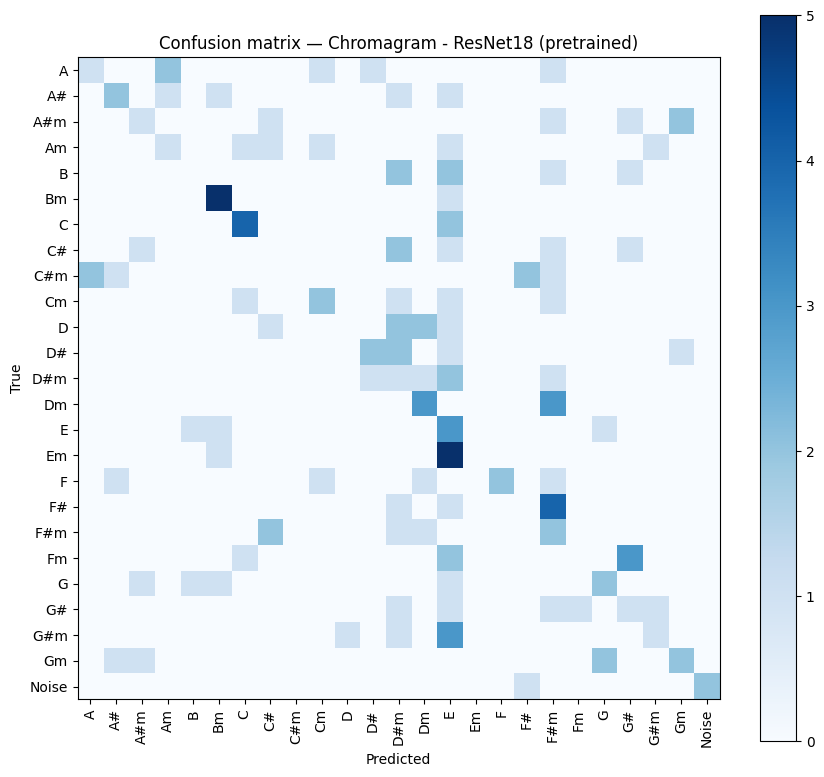

In [22]:
_ = evaluate_and_record("Chromagram - ResNet18 (pretrained)", chroma_resnet_model, chroma_test_loader, use_three_channels=True)

## Comparing All Approaches
For reference, the confusion matrix in `chromagram.ipynb` shows its XGBoost model (trained on 24 hand-crafted mean/std chroma features) getting **112 of 143** test clips correct — about **0.78 accuracy** — with several confusions between closely related chords (e.g. major vs. minor of the same root, such as A vs Am). We add that as a baseline to put the CNN results in context.

In [23]:
results["Chroma (XGBoost baseline, from chromagram.ipynb)"] = {"accuracy": 112 / 143, "macro_f1": None}

comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.sort_values("accuracy", ascending=False)
comparison_df

,accuracy,macro_f1
"Chroma (XGBoost baseline, from chromagram.ipynb)",0.783217,NaN
Spectrogram - CNN from scratch,0.734694,0.702045
Chromagram - CNN from scratch,0.646259,0.611561
Spectrogram - ResNet18 (pretrained),0.251701,0.217534
Chromagram - ResNet18 (pretrained),0.251701,0.251872


## Evaluation: Which Approach Is Better?
Read the sorted `comparison_df` above together with the confusion matrices from each section. A few things to look for, given this dataset has only ~630 training clips spread across 24 chord classes (~26 clips per class):

- **CNN from scratch vs. pretrained ResNet18**: with so little data per class, a CNN trained from scratch has very little signal to learn good convolutional filters and tends to overfit (watch the gap between its train and validation loss curves). The frozen ResNet18 backbone only has to learn a small linear head on top of filters already trained on millions of ImageNet images, so it usually converges faster and generalizes better here — even though those filters were learned on natural photos, not spectrograms. **Transfer learning is the stronger choice on small, specialized datasets like this one.**
- **Spectrogram vs. chromagram as the CNN's input**: chroma collapses everything to the 12 pitch classes that actually define a chord, discarding instrument timbre, octave and overall loudness — exactly the information that doesn't matter for this task. The mel spectrogram keeps 128 frequency bins, most of which describe timbre rather than pitch class, which a CNN has to learn to ignore from very few examples. Expect chroma-based models to do at least as well as spectrogram-based ones, often better.
- **vs. the XGBoost baseline**: XGBoost trains on a compact, already-aggregated 24-feature summary (mean/std chroma per pitch class) rather than raw images, so it needs far fewer examples to fit well. On a dataset this small, it's a strong, hard-to-beat baseline — don't be surprised if it matches or beats both CNN variants. CNNs tend to win once there's enough data (typically hundreds of examples *per class*, not in total) for them to learn features from raw representations rather than relying on hand-crafted ones.

## Further Improvements
- **More data / data augmentation**: this is the single biggest lever for the CNN approaches. Augment with pitch shifting, time stretching, adding noise, or SpecAugment-style time/frequency masking to multiply the effective training set size.
- **Partial fine-tuning of ResNet**: unfreeze the last residual block (instead of the whole backbone) with a small learning rate, so the network can adapt some mid-level features to spectrograms rather than relying purely on the frozen ImageNet head.
- **Audio-specific pretrained models**: instead of an ImageNet CNN, try backbones pretrained directly on audio spectrograms (e.g. PANNs, AST, OpenL3, or embeddings from Wav2Vec2/CLAP) — their pretraining task is much closer to this one than natural image classification.
- **Sequence-aware architectures**: a spectrogram/chromagram is really a time series of frequency vectors. A 1D CNN, RNN/LSTM, or small Transformer over the time axis (rather than treating it as a 2D "image") may model the temporal structure of a strummed chord more naturally.
- **Fuse both representations**: concatenate spectrogram and chroma features (or their CNN embeddings) into a single classifier to combine timbral and pitch-class information.
- **Regularization and training tweaks**: dropout, weight decay, label smoothing, learning-rate scheduling, and early stopping on validation loss would all help the from-scratch CNN generalize better on this small dataset.
- **Proper validation**: use k-fold cross-validation rather than a single train/test split to get a more reliable estimate of accuracy given how small the test set is (~6 clips per chord).
- **Ensembling**: combine the CNN's predictions with the XGBoost model's (e.g. averaging softmax probabilities) — they make different kinds of errors, so an ensemble could outperform either alone.